# Lab 3 — Pulse Shaping, the Nyquist Criterion and the Matched Filter

**Companion to Chapter 8** (*Baseband Transmission and Pulse Shaping*).
**Time needed:** about 60 minutes. **Difficulty:** core.

Symbols are numbers; the channel wants a waveform. The pulse you choose decides how much
spectrum you occupy, how much interference you cause your neighbours and your own past
and future symbols, and how gracefully the receiver tolerates timing error. This lab
builds the raised-cosine family from scratch, proves the zero-ISI condition numerically,
shows why the filter is split into two root-raised-cosine halves, and teaches you to
read an eye diagram like a SerDes engineer. (Line codes, PAM-4 and partial response are
in Lab 13.)

### What you will learn
1. Compare rectangular, sinc and raised-cosine pulses in time and frequency.
2. Verify the Nyquist zero-ISI criterion in both domains, and see what breaks it.
3. Show that the matched filter maximises output SNR, and why RRC is split between TX and RX.
4. Read eye diagrams: opening, timing sensitivity and noise margin.
5. Quantify how truncating the RRC filter leaks power into adjacent channels (ACLR).

### Prerequisites
Lab 2 (constellations, BER). Convolution and the Fourier transform (Chapter 2).

### Roadmap
| § | Topic | Interactive |
|---|-------|:-----------:|
| 1 | Pulse shapes and their spectra | |
| 2 | The Nyquist criterion in both domains | yes |
| 3 | Measuring ISI for different TX/RX pairs | |
| 4 | The matched filter maximises SNR | |
| 5 | Eye diagrams | yes |
| 6 | Timing sensitivity versus roll-off | |
| 7 | Truncation and adjacent-channel leakage | |
| 8 | A glimpse of faster-than-Nyquist signalling | |

In [1]:
import os, sys
os.environ.setdefault("OPENBLAS_NUM_THREADS", "2")   # small matrices: avoid BLAS thread thrashing
sys.path[:0] = [p for p in (os.path.abspath(".."), os.path.abspath("."))
                if os.path.isdir(os.path.join(p, "commlib"))]
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import firwin
import commlib as cl
from commlib import labkit as lk

rng = lk.setup(seed=3, lab="03")
sps = 8                                    # samples per symbol throughout

Lab 03 ready | numpy 2.5.3 | scipy 1.18.1 | matplotlib 3.11.2 | seed 3


## 1. Pulse shapes and their spectra

A rectangular pulse is trivial to generate but its spectrum is a sinc whose sidelobes
decay only 6 dB/octave: it splatters into adjacent channels. The ideal sinc pulse is
perfectly band-limited to $R_s/2$ but its tails decay as $1/t$, so a tiny timing error
sums an unbounded series of ISI terms. The **raised cosine** (RC) with roll-off $\beta$
is the engineering compromise:

$$p_{RC}(t) = \mathrm{sinc}(t/T)\,\frac{\cos(\pi\beta t/T)}{1-(2\beta t/T)^2},$$

occupying exactly $(1+\beta)R_s$ Hz with tails that decay as $1/t^3$.

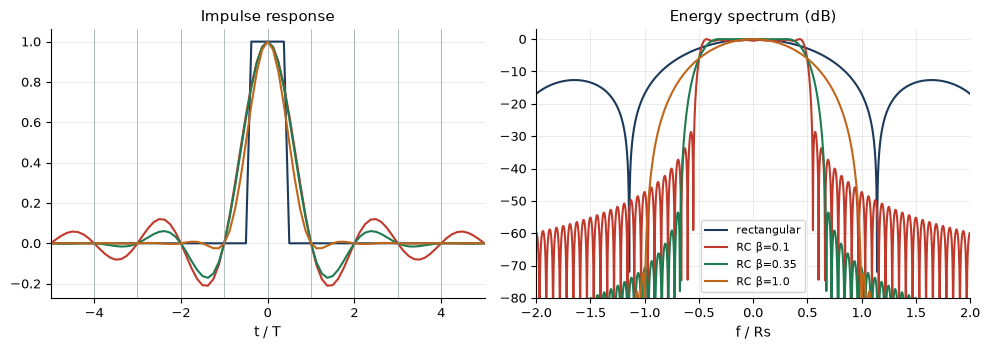

In [3]:
span = 16
t = np.arange(-span * sps / 2, span * sps / 2 + 1) / sps
pulses = {"rectangular": np.where(np.abs(t) < 0.5, 1.0, 0.0),
          "RC β=0.1": cl.rc_taps(0.1, sps, span),
          "RC β=0.35": cl.rc_taps(0.35, sps, span),
          "RC β=1.0": cl.rc_taps(1.0, sps, span)}
f, ax = lk.fig("row2", 1, 2)
for nm, p in pulses.items():
    ax[0].plot(t, p, label=nm)
    P = np.fft.fftshift(np.abs(np.fft.fft(p, 8192)) ** 2)
    fr = np.fft.fftshift(np.fft.fftfreq(8192, 1 / sps))
    ax[1].plot(fr, lk.db(P / P.max()), label=nm)
ax[0].set_xlim(-5, 5); ax[0].set_xlabel("t / T"); ax[0].set_title("Impulse response")
for k in range(-5, 6):
    ax[0].axvline(k, color=lk.GRAY, lw=0.4)
ax[1].set_xlim(-2, 2); ax[1].set_ylim(-80, 3); ax[1].set_xlabel("f / Rs"); ax[1].set_title("Energy spectrum (dB)")
ax[1].legend(fontsize=8)
lk.show(f)

**What you should see.** Every RC pulse passes through zero at each non-zero integer
$t/T$ (grey lines): that is the zero-ISI property. In frequency, the RC spectrum is exactly
zero beyond $(1+\beta)/2$ (the small floor is truncation), while the rectangular pulse's
sidelobes are still only about 30 dB down two symbol rates away.

## 2. The Nyquist criterion in both domains

A pulse $p(t)$ gives zero ISI when sampled at $t = kT$ **if and only if**

$$p(kT) = \delta[k] \quad\Longleftrightarrow\quad \sum_m P\!\left(f - \frac{m}{T}\right) = T .$$

The spectrum's copies, shifted by multiples of the symbol rate, must add to a constant: the
RC's odd-symmetric cosine roll-off around $\pm R_s/2$ fills exactly the hole left by its
neighbour.

### Interactive: the folded spectrum
Try a pulse that is *not* Nyquist, e.g. a Gaussian, and watch the folded sum ripple.

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

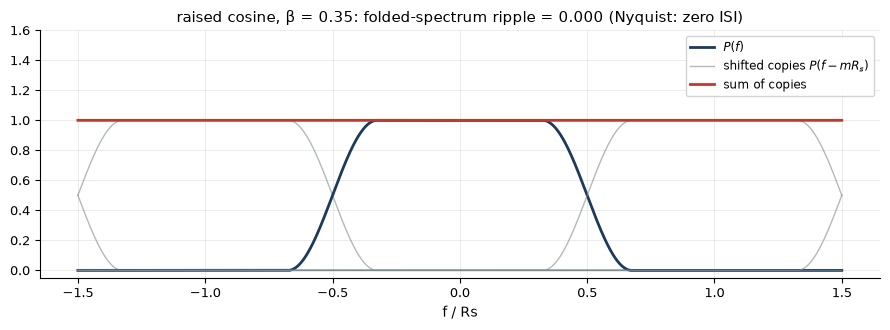

In [6]:
def folded(beta=0.35, pulse="raised cosine"):
    fr = np.linspace(-1.5, 1.5, 3001)
    if pulse == "raised cosine":
        def P(fq):
            a = np.abs(fq); out = np.zeros_like(fq)
            out[a <= (1 - beta) / 2] = 1
            m = (a > (1 - beta) / 2) & (a <= (1 + beta) / 2)
            out[m] = 0.5 * (1 + np.cos(np.pi / beta * (a[m] - (1 - beta) / 2))) if beta > 0 else 0
            return out
    else:  # Gaussian with the same -6 dB bandwidth: not a Nyquist pulse
        P = lambda fq: np.exp(-np.log(2) * (fq / 0.5) ** 2 * 2)        # -6 dB at Rs/2
    f, ax = lk.fig("wide")
    tot = np.zeros_like(fr)
    for m in range(-3, 4):
        c = P(fr - m)
        tot += c
        ax.plot(fr, c, color=lk.GRAY if m else lk.NAVY, lw=1 if m else 2, alpha=0.6 if m else 1,
                label="$P(f)$" if m == 0 else ("shifted copies $P(f - m R_s)$" if m == 1 else None))
    ax.plot(fr, tot, color=lk.RED, lw=2, label="sum of copies")
    ax.set_xlabel("f / Rs"); ax.set_ylim(-0.05, 1.6); ax.legend(loc="upper right")
    ripple = tot.max() - tot.min()
    ax.set_title(f"{pulse}, β = {beta:.2f}: folded-spectrum ripple = {ripple:.3f} "
                 f"({'Nyquist: zero ISI' if ripple < 1e-6 else 'NOT Nyquist: ISI'})")
    lk.show(f)

lk.interact(folded, beta=lk.slider(0.35, 0.0, 1.0, 0.05, "roll-off β"),
            pulse=lk.choice(["raised cosine", "Gaussian"], desc="pulse"))

**What you should see.** For the raised cosine the red sum is perfectly flat for every
$\beta$. Switch to the Gaussian: the sum ripples, so the pulse causes ISI at the
sampling instants (which is why GMSK needs an equalizer or a Viterbi detector for BT = 0.3).

## 3. Measuring ISI for different TX/RX pairs

The criterion applies to the **end-to-end** pulse, transmit filter convolved with receive
filter. We build a 16-QAM waveform and measure the residual ISI power (relative to the
signal) at the optimum sampling instant for several combinations.

In [9]:
c16 = cl.get_constellation("16qam")
s16 = c16.modulate(cl.random_bits(4 * 4000, rng))

def isi_power(tx, rx):
    y = np.convolve(cl.shape(s16, tx, sps), rx)
    d = int(np.argmax(np.abs(np.convolve(tx, rx))))       # peak of the end-to-end pulse
    z = y[d::sps][:len(s16)]
    g = np.vdot(s16, z) / np.vdot(s16, s16)
    return max(lk.db(np.mean(np.abs(z / g - s16)[50:-50] ** 2)), -100.0)   # -100 = numerical floor

rrc = cl.rrc_taps(0.35, sps, 12)
rc = cl.rc_taps(0.35, sps, 12); rc /= np.sqrt(np.sum(rc ** 2))
rect = np.ones(sps) / np.sqrt(sps)
rows = [["RRC → RRC", isi_power(rrc, rrc), "the standard split"],
        ["RC → nothing", isi_power(rc, np.array([1.0])), "Nyquist, but no noise filtering"],
        ["RC → RC", isi_power(rc, rc), "RC*RC is not Nyquist"],
        ["rect → rect", isi_power(rect, rect), "triangle: Nyquist"],
        ["RRC 0.35 → RRC 0.20", isi_power(rrc, cl.rrc_taps(0.2, sps, 12)), "roll-off mismatch"],
        ["RRC → boxcar", isi_power(rrc, rect), "mismatched receiver"]]
lk.table(rows, ["TX → RX", "residual ISI (dB)", "comment"], fmt={1: ".1f"})

TX → RX,residual ISI (dB),comment
RRC → RRC,-53.9,the standard split
RC → nothing,-100.0,"Nyquist, but no noise filtering"
RC → RC,-15.1,RC*RC is not Nyquist
rect → rect,-100.0,triangle: Nyquist
RRC 0.35 → RRC 0.20,-37.9,roll-off mismatch
RRC → boxcar,-20.6,mismatched receiver


**What you should see.** RC→nothing and rect→rect reach the numerical floor (shown as
−100 dB); RRC→RRC is around −54 dB, limited only by truncating the filters to 12 symbols. RC followed by another RC filter
is catastrophic for 16-QAM (−15 dB of ISI is a visible error floor), and so is a boxcar
receiver after an RRC transmitter. A small roll-off
mismatch between TX and RX, a common bug when two teams choose "their" β, costs a
floor near −38 dB: harmless for QPSK, fatal for 1024-QAM.

## 4. The matched filter maximises SNR

For a pulse $p(t)$ in white noise, the receive filter that maximises the sampled output
SNR is $h(t) = p^*(-t)$, and the maximum is $2E_p/N_0$ (Cauchy–Schwarz). Choosing
RRC at both ends makes the receiver matched to the transmitter *and* the end-to-end pulse
Nyquist: optimal SNR and zero ISI at once. We compare against three plausible alternatives,
first analytically (output SNR) and then by Monte Carlo BER.

In [12]:
cands = {"matched RRC": rrc, "moving average (1 symbol)": np.ones(sps) / sps,
         "low-pass, cutoff 1.0 Rs": firwin(97, 1.0 / (sps / 2)),
         "low-pass, cutoff 0.4 Rs": firwin(97, 0.4 / (sps / 2))}
qpsk = cl.get_constellation("qpsk")
bits = cl.random_bits(2 * 50_000, rng)
tx = cl.shape(qpsk.modulate(bits), rrc, sps)
es_n0 = 7.0
y, _ = cl.awgn_esn0(tx, es_n0, sps=sps, rng=rng)
rows = []
for nm, h in cands.items():
    e2e = np.convolve(rrc, h)
    d = int(np.argmax(np.abs(e2e)))
    snr = lk.db(np.max(np.abs(e2e)) ** 2 / np.sum(np.abs(h) ** 2))        # N0 = 1
    z = np.convolve(y, h)[d::sps][:len(bits) // 2]
    ber = np.mean(qpsk.demodulate(z / np.abs(e2e[d])) != bits)
    rows.append([nm, snr, ber])
lk.table(rows, ["receive filter", "peak SNR / (Es/N0) (dB)", f"QPSK BER at Es/N0 = {es_n0} dB"],
         fmt={1: ".2f", 2: ".2e"})
print(f"Theory for the matched filter: BER = {cl.ber_bpsk(es_n0 - 3.01):.2e}")

receive filter,peak SNR / (Es/N0) (dB),QPSK BER at Es/N0 = 7.0 dB
matched RRC,0.00,1.20e-02
moving average (1 symbol),-0.75,2.11e-02
"low-pass, cutoff 1.0 Rs",-2.07,4.17e-02
"low-pass, cutoff 0.4 Rs",-0.68,5.65e-02


Theory for the matched filter: BER = 1.26e-02


**What you should see.** The matched filter achieves 0.00 dB (all of $E_s/N_0$ is
delivered) and the lowest BER, matching theory. The wide low-pass lets in extra noise;
the narrow one and the moving average both lose SNR *and* add ISI.

## 5. Eye diagrams

Overlaying many symbol-length slices of the received waveform gives the **eye diagram**.
Its vertical opening at the best sampling instant is the noise margin; its horizontal
opening is the tolerance to timing jitter. The *density* view on the right is what a
sampling oscilloscope's persistence mode shows.

### Interactive: eye explorer
Small β saves bandwidth but narrows the eye horizontally. Try the mismatched receivers.

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

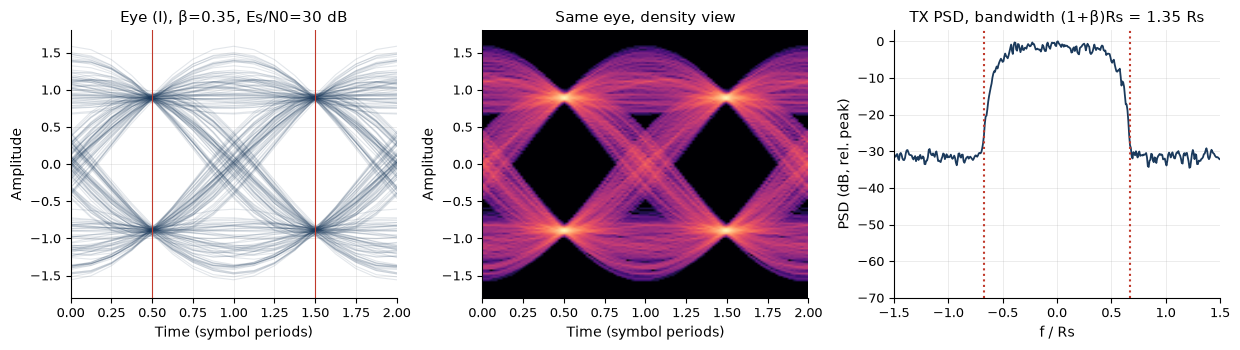

In [15]:
def eye(beta=0.35, esn0_db=30.0, mod="qpsk", pair="RRC → RRC"):
    cc = cl.get_constellation(mod)
    sym = cc.modulate(cl.random_bits(cc.k * 1500, rng))
    h = cl.rrc_taps(beta, sps, 12)
    if pair == "RRC → RRC":
        tx_, rx_ = h, h
    elif pair == "RC → nothing":
        tx_ = cl.rc_taps(beta, sps, 12); tx_ = tx_ / np.sqrt(np.sum(tx_ ** 2)); rx_ = np.array([1.0])
    else:
        tx_, rx_ = h, np.ones(sps) / np.sqrt(sps)
    x = cl.shape(sym, tx_, sps)
    x, _ = cl.awgn_esn0(x, esn0_db, sps=sps, rng=rng)
    yy = np.convolve(x, rx_)
    d = (len(tx_) - 1) // 2 + (len(rx_) - 1) // 2
    yy = yy / np.max(np.abs(yy[d::sps][50:-50].real))
    seg = yy[d - sps // 2 + 100 * sps: -100 * sps]
    f, ax = lk.fig("row3", 1, 3)
    lk.eye(ax[0], seg, sps, 2)
    for v in (0.5, 1.5):
        ax[0].axvline(v, color=lk.RED, lw=0.8)
    ax[0].set_ylim(-1.8, 1.8); ax[0].set_title(f"Eye (I), β={beta:.2f}, Es/N0={esn0_db:.0f} dB")
    lk.eye_density(ax[1], seg, sps, 2, ylim=1.8); ax[1].set_title("Same eye, density view")
    lk.psd(ax[2], x, sps, 1024)
    ax[2].set_xlim(-1.5, 1.5); ax[2].set_ylim(-70, 3)
    for s_ in (-1, 1):
        ax[2].axvline(s_ * (1 + beta) / 2, color=lk.RED, ls=":")
    ax[2].set_xlabel("f / Rs"); ax[2].set_title(f"TX PSD, bandwidth (1+β)Rs = {1 + beta:.2f} Rs")
    lk.show(f)

lk.interact(eye, beta=lk.slider(0.35, 0.05, 1.0, 0.05, "β"), esn0_db=lk.slider(30, 5, 40, 1, "Es/N0 (dB)"),
            mod=lk.choice(["bpsk", "qpsk", "16qam", "64qam"], "qpsk", "modulation"),
            pair=lk.choice(["RRC → RRC", "RC → nothing", "RRC → boxcar (mismatched)"], desc="filters"))

**What you should see.** A wide-open eye at the red lines (the symbol instants). With the
boxcar receiver the traces no longer converge to single points: ISI. Lower the SNR and the
eye fills in vertically; lower β and it pinches horizontally.

## 6. Timing sensitivity versus roll-off

QPSK at $E_s/N_0 = 10$ dB, sampled $\epsilon T$ away from the optimum instant. The larger
the roll-off, the faster the pulse tails decay and the more timing error the link tolerates.

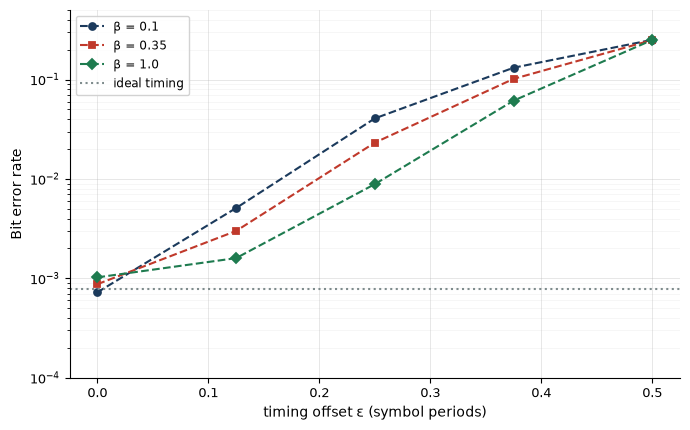

In [18]:
bits6 = cl.random_bits(2 * 20000, rng)
sym6 = qpsk.modulate(bits6)
offs = np.arange(0, sps // 2 + 1)
bers = {}
for beta in [0.1, 0.35, 1.0]:
    h = cl.rrc_taps(beta, sps, 16)
    yy = cl.matched_filter(cl.awgn_esn0(cl.shape(sym6, h, sps), 10, sps=sps, rng=rng)[0], h)
    d = len(h) - 1
    bers[f"β = {beta}"] = [np.mean(qpsk.demodulate(yy[d + o::sps][:len(sym6)]) != bits6) for o in offs]
f, ax = lk.fig("ber")
lk.ber_plot(ax, offs / sps, bers, xlabel="timing offset ε (symbol periods)", ylim=(1e-4, 0.5))
ax.axhline(cl.ber_bpsk(10 - 3.01), color=lk.GRAY, ls=":", label="ideal timing")
ax.legend()
lk.show(f)

**What you should see.** At $\epsilon = 0$ all roll-offs give the same BER. At
$\epsilon = 0.25$ the β = 0.1 link has about four to five times the BER of the β = 1.0 link. This
is why a DVB-S2 modem using β = 0.05–0.2 needs a very good timing loop (Lab 4).

## 7. Truncation and adjacent-channel leakage

A real RRC filter has finite length. Truncating the $1/t^3$ tails puts a floor under the
spectrum and leaks power into the neighbouring channel. The **adjacent-channel leakage
ratio** (ACLR) is the power in the adjacent channel, here
$[\tfrac12(1+\beta),\ \tfrac32(1+\beta)]R_s$, relative to the in-band power. 3GPP base
stations must meet about 45 dB (TS 38.104); the pulse-shaping filter is only one of
several contributors (the PA is usually the worst).

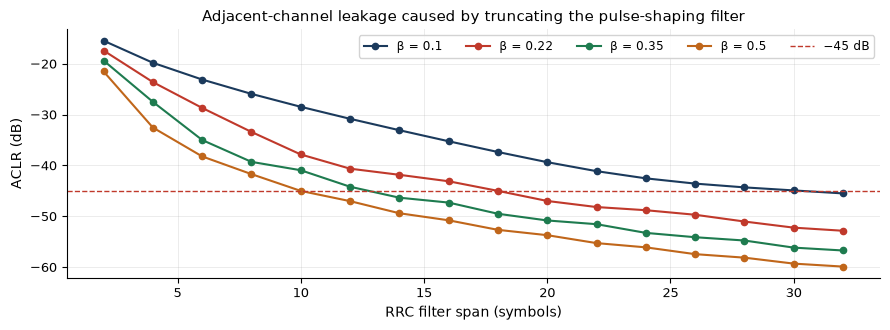

In [21]:
def aclr_db(beta, span_sym, nfft=1 << 15):
    h = cl.rrc_taps(beta, sps, span_sym)
    H = np.abs(np.fft.fft(h, nfft)) ** 2
    fr = np.abs(np.fft.fftfreq(nfft, 1 / sps))
    b = (1 + beta) / 2
    return lk.db(np.sum(H[(fr > b) & (fr <= 3 * b)]) / np.sum(H[fr <= b]))

spans = np.arange(2, 33, 2)
f, ax = lk.fig("wide")
for beta in [0.1, 0.22, 0.35, 0.5]:
    ax.plot(spans, [aclr_db(beta, s_) for s_ in spans], "o-", label=f"β = {beta}")
ax.axhline(-45, color=lk.RED, ls="--", lw=1, label="−45 dB")
ax.set_xlabel("RRC filter span (symbols)"); ax.set_ylabel("ACLR (dB)"); ax.legend(ncol=5, loc="upper right")
ax.set_title("Adjacent-channel leakage caused by truncating the pulse-shaping filter")
lk.show(f)

**What you should see.** Longer filters leak less, with diminishing returns; small
roll-offs need much longer filters for the same ACLR because their tails decay more slowly.

### Try it yourself 7.1
What is the shortest even span (in symbols) for which a β = 0.22 RRC filter (the value used
by WCDMA/UMTS) achieves an ACLR below −45 dB? Use `aclr_db`.

In [23]:
answer_7_1 = None
lk.check("7.1 shortest span for ACLR < -45 dB at β = 0.22", answer_7_1,
         next(s_ for s_ in range(2, 80, 2) if aclr_db(0.22, s_) < -45), atol=0)

[TODO] 7.1 shortest span for ACLR < -45 dB at β = 0.22: not attempted yet: replace the None with your answer

## 8. A glimpse of faster-than-Nyquist signalling

Nyquist says you cannot send faster than $2W$ symbols/s *without ISI*. Mazo showed in 1975
that you can squeeze sinc/RC pulses closer together, $\tau T$ with $\tau < 1$, and (up to
$\tau \approx 0.802$ for binary sinc pulses) the minimum Euclidean distance does not shrink,
so an ML sequence detector loses nothing. The price is deliberate ISI, visible below, which
only a trellis or iterative receiver can undo (Chapter 8 and Chapter 12).

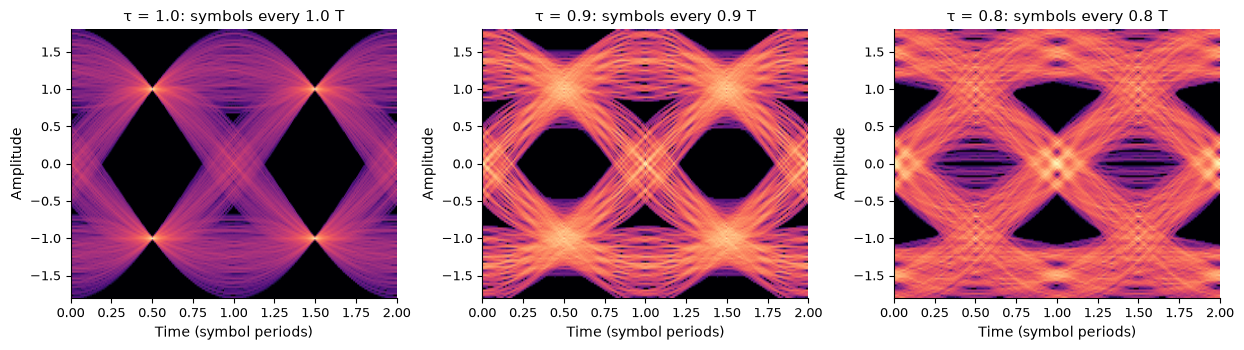

In [25]:
f, ax = lk.fig("row3", 1, 3)
b8 = 2.0 * cl.random_bits(3000, rng) - 1
h8 = cl.rrc_taps(0.3, 20, 16)
for a, tau in zip(ax, [1.0, 0.9, 0.8]):
    step = int(round(20 * tau))                          # samples between symbols
    up = np.zeros(len(b8) * step); up[::step] = b8
    yy = np.convolve(np.convolve(up, h8), h8)
    d = len(h8) - 1
    lk.eye_density(a, yy[d - step // 2 + 50 * step:-50 * step], step, 2, ylim=1.8)
    a.set_title(f"τ = {tau}: symbols every {tau} T")
lk.show(f)

**What you should see.** At τ = 1 the binary eye is wide open; at τ = 0.9 it narrows; at
τ = 0.8 it is almost closed, although the information is still recoverable by an
ML sequence detector. 25% more throughput in the same bandwidth, bought with receiver complexity.

## Key takeaways
* Zero ISI ⟺ the folded spectrum is flat ⟺ $p(kT) = \delta[k]$. The raised cosine meets it
  with bandwidth $(1+\beta)R_s$ for any β.
* Split the RC into two RRCs: the receiver is then matched (maximum SNR) *and* ISI-free.
* Eye diagrams show noise margin vertically and timing margin horizontally; small β
  narrows the horizontal opening.
* Filter truncation sets an ACLR floor; small β needs long filters.

## Going further (hardware: USRP B200 / GNU Radio)
* In `gnuradio/gr02_psk_link.py`, change the RRC roll-off at the transmitter only and watch
  the constellation spread: Section 3's mismatch, live.
* Transmit an RRC-shaped QPSK signal through the B200 (with an attenuator) and measure its
  spectrum with gr01. Compare the shoulder level with Section 7; the difference is the
  B200's own transmit nonlinearity.
* Lab 13 continues with line codes, jitter, bathtub curves, PAM-4 and duobinary.

## Exercises
1. **(Warm-up)** Show that the RC spectrum satisfies the Nyquist folding condition.
2. **(Core)** Implement a polyphase interpolator that produces the RRC waveform at sps = 8
   using 8 sub-filters, and verify it matches `cl.shape` exactly (see Lab 17).
3. **(Core)** Derive the output-SNR loss of the moving-average receiver in Section 4 and
   compare with the table.
4. **(Stretch)** Design a Nyquist pulse by least squares with a stop-band constraint
   (e.g. `scipy.signal.remez` on the RRC square-root spectrum) that beats the truncated RRC in
   ACLR for the same length, and check its residual ISI with `isi_power`.

In [28]:
lk.summary()

[good] Lab 03 finished in 2.4 s. Self-checks: 0 passed, 0 failed, 1 still to do.